In [1]:
# importing Python Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split


# Context:

 According to the World Health Organization (WHO),stroke is the 2nd leading cause of death globally,responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status

Attribute Information
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

In [3]:
#loading the dataset

data = pd.read_csv('healthcare-dataset-stroke-data.csv')



# used to return the first 5 rows of a dataset
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# used to return the last 5 rows of a dataset
data.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
# used to get the data types of the columns in a dataset
data.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [6]:
# to get the summary of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
# used to generate descriptive statistics of the dataset
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
# get the dimensions of an array(rows,columns)
data.shape

(5110, 12)

In [9]:
#Checking null values in each columns
data.isna().sum() 

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
#Count the number of duplicates 
data.duplicated().sum()


0

In [11]:
dat= data.copy()

# Removing unwanted data

In [12]:
data.drop(['id'],axis=1,inplace=True)

In [13]:
data.dropna(axis=0,inplace=True)

In [14]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [15]:
data.isna().sum() 

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

# Data visualization 

In [16]:
 #Pie chart

In [17]:
dat['hypertension'].replace({0: 'does not have hypertension', 1: 'have hypertension'}, inplace=True)
dat['heart_disease'].replace({0:' does no thave heart disease', 1: ' have heart disease'}, inplace=True)

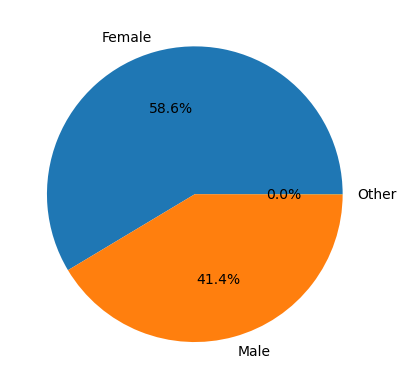

In [18]:
ab = dat['gender'].value_counts()
plt.pie( ab, labels=ab.index, autopct='%1.1f%%')
plt.show()

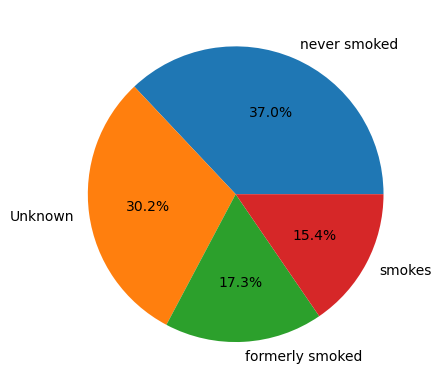

In [19]:
ab =dat['smoking_status'].value_counts()
plt.pie( ab, labels=ab.index, autopct='%1.1f%%')
plt.show()

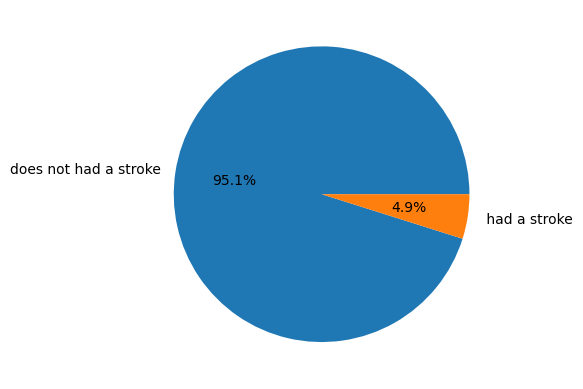

In [20]:
dat['stroke'].replace({0: 'does not had a stroke', 1: ' had a stroke'}, inplace=True)


ab =dat['stroke'].value_counts()
plt.pie( ab, labels=ab.index, autopct='%1.1f%%')
plt.show()

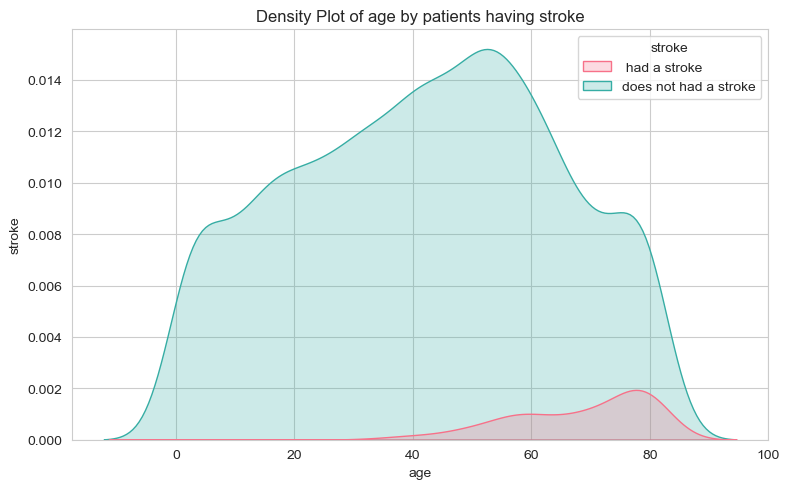

In [21]:
#Density Plot

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.kdeplot(data=dat, x='age', hue='stroke', fill=True, palette='husl')

plt.title('Density Plot of age by patients having stroke')
plt.xlabel('age')
plt.ylabel('stroke')

plt.tight_layout()
plt.show()

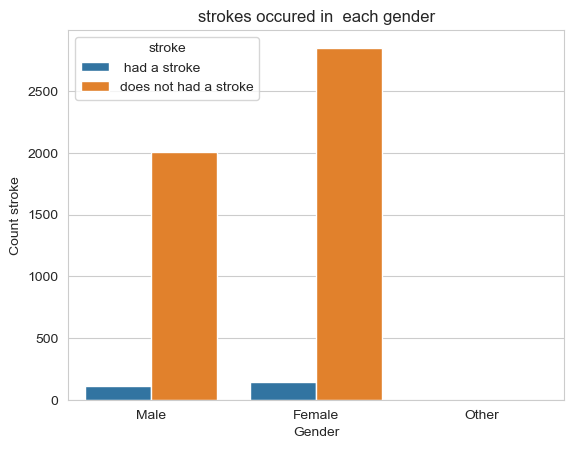

In [22]:
#Bar Graph


sns.countplot(data=dat, x='gender', hue='stroke')
plt.title('strokes occured in  each gender')
plt.xlabel('Gender')
plt.ylabel('Count stroke')
plt.show()

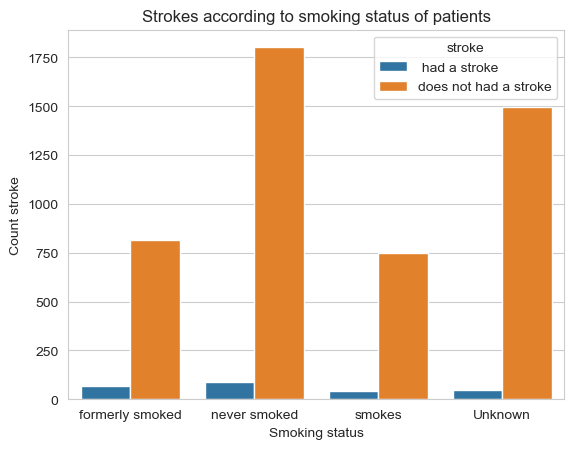

In [23]:
sns.countplot(data=dat, x='smoking_status', hue='stroke')

plt.title('Strokes according to smoking status of patients')
plt.xlabel('Smoking status')
plt.ylabel('Count stroke')
plt.show()

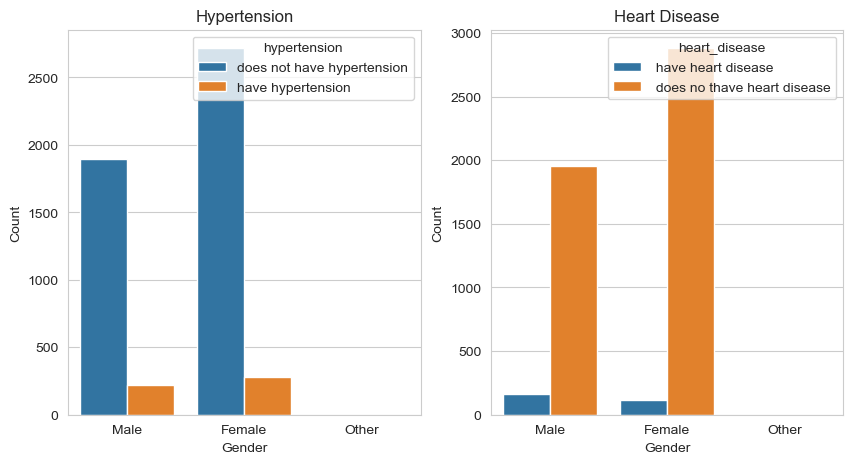

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 1st barplot: Hypertension by Gender
sns.countplot(data=dat, x='gender', hue='hypertension', ax=axes[0])
axes[0].set_title('Hypertension')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# 2nd barplot: Heart Disease by Gender
sns.countplot(data=dat, x='gender', hue='heart_disease', ax=axes[1])
axes[1].set_title('Heart Disease')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.show()

# data preparation

In [25]:
# DATA ENCODING : Replacing string types into integer types

In [26]:
data['heart_disease']

0       1
2       1
3       0
4       0
5       0
       ..
5104    0
5106    0
5107    0
5108    0
5109    0
Name: heart_disease, Length: 4909, dtype: int64

In [27]:
data['hypertension']

0       0
2       0
3       0
4       1
5       0
       ..
5104    0
5106    0
5107    0
5108    0
5109    0
Name: hypertension, Length: 4909, dtype: int64

In [28]:
#  finds the unique elements
data['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [29]:
#replacing the values

mapping={'Yes':1,'No':0}
data['ever_married']=data['ever_married'].map(mapping)

In [30]:
data['ever_married']

0       1
2       1
3       1
4       1
5       1
       ..
5104    0
5106    1
5107    1
5108    1
5109    1
Name: ever_married, Length: 4909, dtype: int64

In [31]:
data['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [32]:
mapping={'Private':0,'Self-employed':1, 'Govt_job':2, 'children':3,'Never_worked':4}
data['work_type']=data['work_type'].map(mapping)

In [33]:
data['work_type']

0       0
2       0
3       0
4       1
5       0
       ..
5104    3
5106    1
5107    1
5108    0
5109    2
Name: work_type, Length: 4909, dtype: int64

In [34]:
mapping={'Urban':0,'Rural':1}
data['Residence_type']=data['Residence_type'].map(mapping)

In [35]:
mapping={'formerly smoked':0,'never smoked':1,'smokes':2,'Unknown':3}
data['smoking_status']=data['smoking_status'].map(mapping)

In [36]:
mapping={'Female':0,'Male':1, 'Other':2}
data['gender']=data['gender'].map(mapping)

In [37]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,0,228.69,36.6,0,1
2,1,80.0,0,1,1,0,1,105.92,32.5,1,1
3,0,49.0,0,0,1,0,0,171.23,34.4,2,1
4,0,79.0,1,0,1,1,1,174.12,24.0,1,1
5,1,81.0,0,0,1,0,0,186.21,29.0,0,1


In [38]:
data.dtypes

gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object

In [39]:
#heat map

In [40]:
data.corr()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.000000,-0.030738,0.021578,0.082712,-0.037237,0.070316,0.005014,0.053664,-0.026678,0.038252,0.006757
age,-0.030738,1.000000,0.274425,0.257123,0.680782,-0.415344,-0.010948,0.235838,0.333398,-0.386676,0.232331
hypertension,0.021578,0.274425,1.000000,0.115991,0.162406,-0.073404,0.001074,0.180543,0.167811,-0.132832,0.142515
heart_disease,0.082712,0.257123,0.115991,1.000000,0.111245,-0.054927,0.002362,0.154525,0.041357,-0.071397,0.137938
ever_married,-0.037237,0.680782,0.162406,0.111245,1.000000,-0.377806,-0.004989,0.151377,0.341695,-0.310702,0.105089
work_type,0.070316,-0.415344,-0.073404,-0.054927,-0.377806,1.000000,-0.013084,-0.063152,-0.347241,0.313308,-0.057534
Residence_type,0.005014,-0.010948,0.001074,0.002362,-0.004989,-0.013084,1.000000,0.007617,0.000122,-0.002719,-0.006031
avg_glucose_level,0.053664,0.235838,0.180543,0.154525,0.151377,-0.063152,0.007617,1.000000,0.175502,-0.108984,0.138936
bmi,-0.026678,0.333398,0.167811,0.041357,0.341695,-0.347241,0.000122,0.175502,1.000000,-0.235740,0.042374
smoking_status,0.038252,-0.386676,-0.132832,-0.071397,-0.310702,0.313308,-0.002719,-0.108984,-0.235740,1.000000,-0.075920


<Axes: >

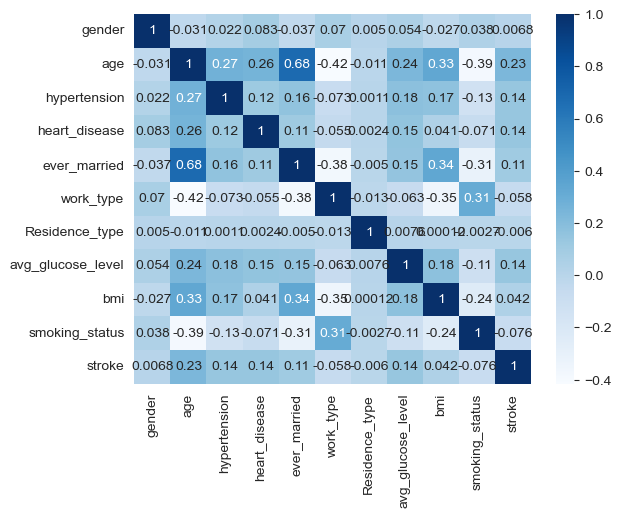

In [41]:
correlation =  data.corr()
sns.heatmap(correlation,cmap="Blues",annot=True)

###   Treating Outliers

**OUTLIER**

An Outlier is an observation in a given dataset that lies far from the rest of the observations.That means an outlier is vastly larger or smaller than the remaining values in the set.

Text(0.5, 1.0, 'heart_disease')

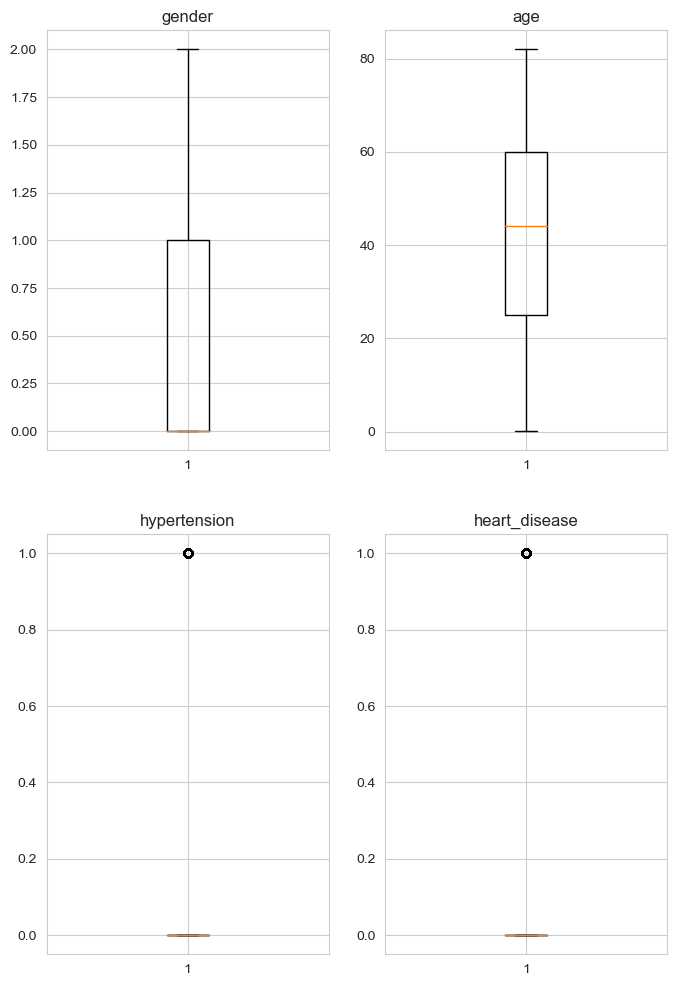

In [42]:
# checking for outliers using boxplot 

#1

fig,ax = plt.subplots(2,2,figsize =(8,12))
ax[0,0].boxplot(x= 'gender' , data=data)
ax[0,0].set_title("gender")
ax[0,1].boxplot(x= 'age' , data=data)
ax[0,1].set_title("age")
ax[1,0].boxplot(x= 'hypertension' , data=data)
ax[1,0].set_title("hypertension")
ax[1,1].boxplot(x= 'heart_disease' , data=data)
ax[1,1].set_title("heart_disease")


Text(0.5, 1.0, 'avg_glucose_level')

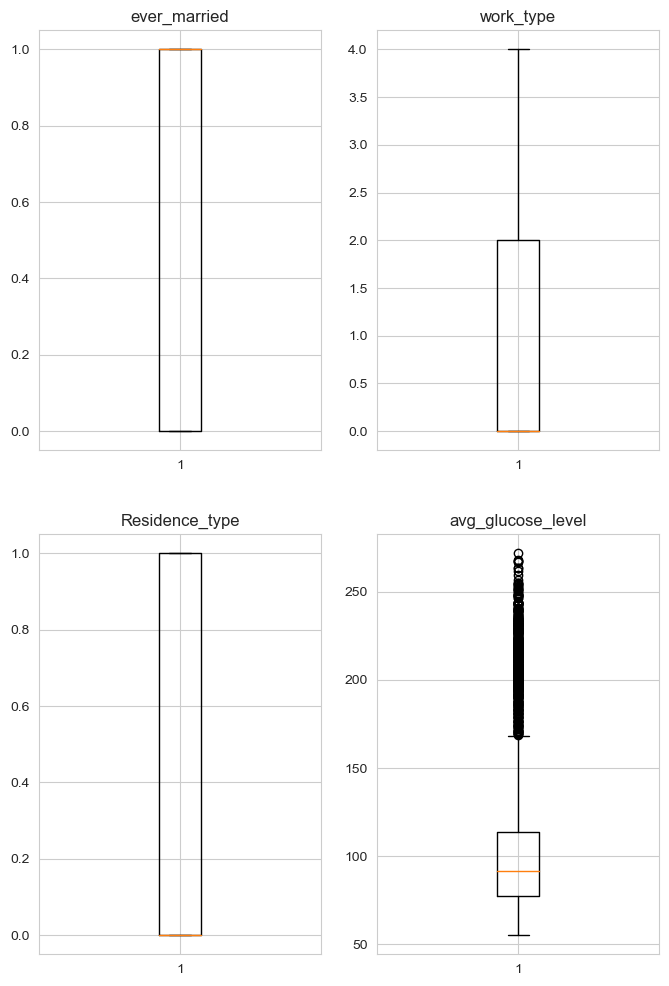

In [43]:
#2

fig,bx = plt.subplots(2,2,figsize =(8,12))
bx[0,0].boxplot(x= 'ever_married' , data=data)
bx[0,0].set_title("ever_married")
bx[0,1].boxplot(x= 'work_type' , data=data)
bx[0,1].set_title("work_type")
bx[1,0].boxplot(x= 'Residence_type' , data=data)
bx[1,0].set_title("Residence_type")
bx[1,1].boxplot(x= 'avg_glucose_level' , data=data)
bx[1,1].set_title("avg_glucose_level")

Text(0.5, 1.0, 'avg_glucose_level')

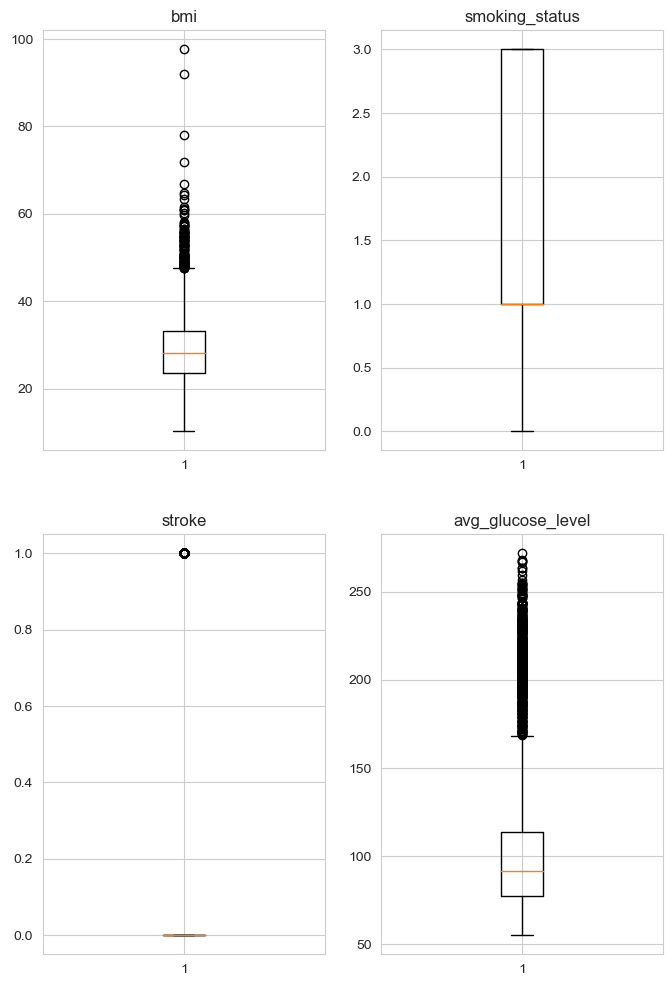

In [44]:
#3

fig,cx = plt.subplots(2,2,figsize =(8,12))
cx[0,0].boxplot(x= 'bmi' , data=data)
cx[0,0].set_title("bmi")
cx[0,1].boxplot(x= 'smoking_status' , data=data)
cx[0,1].set_title("smoking_status")
cx[1,0].boxplot(x= 'stroke' , data=data)
cx[1,0].set_title("stroke")
cx[1,1].boxplot(x= 'avg_glucose_level' , data=data)
cx[1,1].set_title("avg_glucose_level")

Treating Outliers using  Inter Quantile Range method

##     Inter Quantile Range(IQR)

IQR is the range between the first and the third quartiles namely Q1 and Q3: IQR = Q3 – Q1. The data points which fall below Q1 – 1.5 IQR or above Q3 + 1.5 IQR are outliers

In [45]:
edata = data.copy()
edata

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,0,228.69,36.6,0,1
2,1,80.0,0,1,1,0,1,105.92,32.5,1,1
3,0,49.0,0,0,1,0,0,171.23,34.4,2,1
4,0,79.0,1,0,1,1,1,174.12,24.0,1,1
5,1,81.0,0,0,1,0,0,186.21,29.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,0,13.0,0,0,0,3,1,103.08,18.6,3,0
5106,0,81.0,0,0,1,1,0,125.20,40.0,1,0
5107,0,35.0,0,0,1,1,1,82.99,30.6,1,0
5108,1,51.0,0,0,1,0,1,166.29,25.6,0,0


In [46]:
#  avg_glucose_level

In [47]:
Q1 = data['avg_glucose_level'].quantile(0.25)
Q3 = data['avg_glucose_level'].quantile(0.75)

IQR = Q3 - Q1

In [48]:
Q1, Q3, IQR

(77.07, 113.57, 36.5)

In [49]:
upper = Q3 + (1.5 * IQR)
lower = Q1 - (1.5 * IQR)




lower , upper

(22.319999999999993, 168.32)

<Axes: xlabel='avg_glucose_level'>

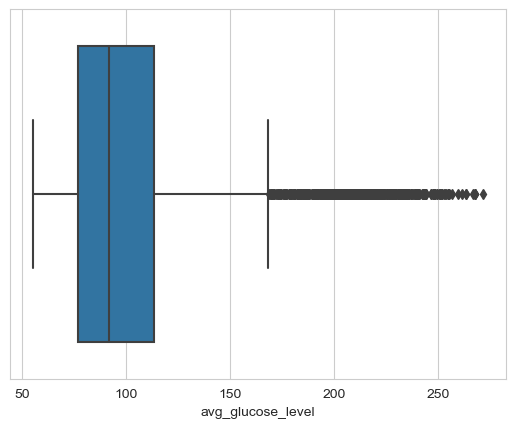

In [50]:
sns.boxplot(x='avg_glucose_level',data=data)

In [51]:
#find outliers 
data.loc[(data['avg_glucose_level'] > upper) | (data['avg_glucose_level'] < lower)]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,0,228.69,36.6,0,1
3,0,49.0,0,0,1,0,0,171.23,34.4,2,1
4,0,79.0,1,0,1,1,1,174.12,24.0,1,1
5,1,81.0,0,0,1,0,0,186.21,29.0,0,1
14,0,79.0,0,1,1,0,0,214.09,28.2,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5061,1,41.0,0,0,1,0,0,223.78,32.3,1,0
5062,0,82.0,0,0,1,1,1,211.58,36.9,1,0
5063,1,39.0,0,0,1,0,0,179.38,27.7,3,0
5064,1,70.0,0,0,1,1,1,193.88,24.3,3,0


In [52]:
data.shape

(4909, 11)

In [53]:
#trim
newd = edata.loc[(data['avg_glucose_level'] < upper) & (data['avg_glucose_level'] > lower)]

<Axes: xlabel='avg_glucose_level'>

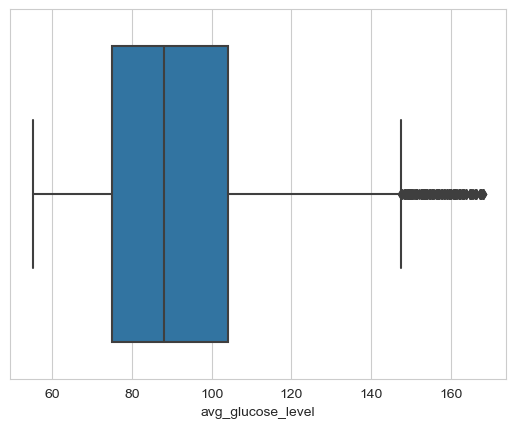

In [54]:
sns.boxplot(x='avg_glucose_level',data=newd)

In [55]:
newd = data.copy()

#capping - change the outliers values to upper or lower limit values

newd.loc[(newd['avg_glucose_level']>upper), 'avg_glucose_level'] = upper
newd.loc[(newd['avg_glucose_level']<lower), 'avg_glucose_level'] = lower

<Axes: xlabel='avg_glucose_level'>

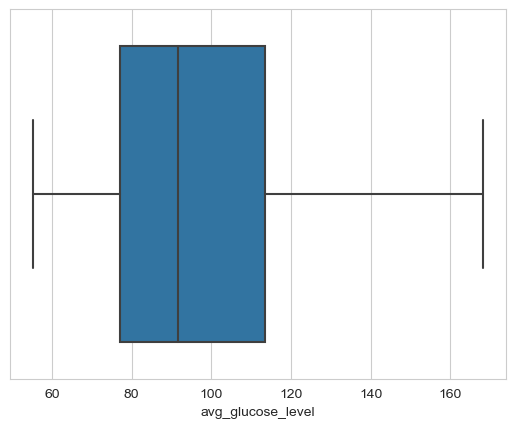

In [56]:
sns.boxplot(x='avg_glucose_level',data=newd)

In [57]:

#bmi

Q1 = data['bmi'].quantile(0.25)
Q3 = data['bmi'].quantile(0.75)

IQR = Q3 - Q1

In [58]:
Q1, Q3, IQR

(23.5, 33.1, 9.600000000000001)

In [59]:
upperl = Q3 + (1.5 * IQR)
lowerl = Q1 - (1.5 * IQR)




lowerl , upperl

(9.099999999999998, 47.5)

<Axes: xlabel='bmi'>

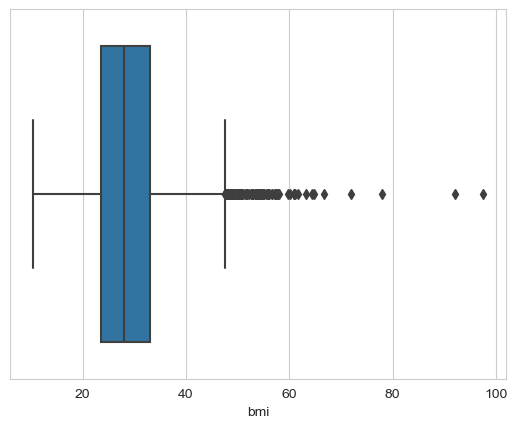

In [60]:
sns.boxplot(x='bmi',data=data)

In [61]:
data.loc[(data['bmi'] > upperl) | (data['bmi'] < lowerl)]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
21,0,52.0,1,0,1,1,0,233.29,48.9,1,1
113,0,45.0,0,0,1,0,1,224.10,56.6,1,1
254,0,47.0,0,0,1,0,0,210.95,50.1,3,0
258,0,74.0,1,0,1,1,0,205.84,54.6,1,0
270,0,57.0,1,0,1,0,1,129.54,60.9,2,0
...,...,...,...,...,...,...,...,...,...,...,...
4858,0,43.0,0,0,1,0,0,100.88,47.6,2,0
4906,0,53.0,0,0,1,0,0,70.51,54.1,1,0
4952,1,51.0,1,0,1,1,1,211.83,56.6,1,0
5009,0,50.0,0,0,1,1,1,126.85,49.5,0,0


In [62]:
data.shape

(4909, 11)

In [63]:
new = data.loc[(data['bmi'] < upperl) & (data['bmi'] > lowerl)]

In [64]:
new = data.copy()


new.loc[(new['bmi']>upperl), 'bmi'] = upperl
new.loc[(new['bmi']<lowerl), 'bmi'] = lowerl

<Axes: xlabel='bmi'>

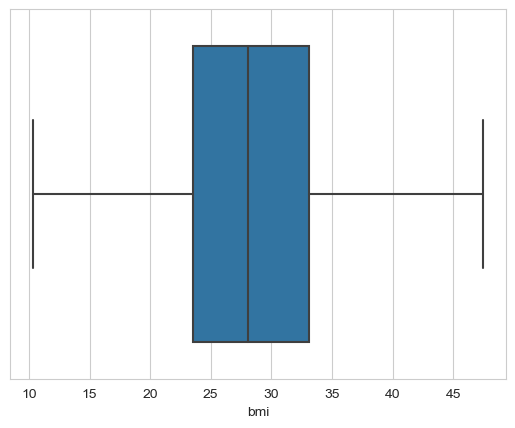

In [65]:
sns.boxplot(x='bmi',data=new)

In [66]:
data.shape

(4909, 11)

In [67]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,0,228.69,36.6,0,1
2,1,80.0,0,1,1,0,1,105.92,32.5,1,1
3,0,49.0,0,0,1,0,0,171.23,34.4,2,1
4,0,79.0,1,0,1,1,1,174.12,24.0,1,1
5,1,81.0,0,0,1,0,0,186.21,29.0,0,1


##  data spliting

In [68]:
data["stroke"].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

In [69]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,0,228.69,36.6,0,1
2,1,80.0,0,1,1,0,1,105.92,32.5,1,1
3,0,49.0,0,0,1,0,0,171.23,34.4,2,1
4,0,79.0,1,0,1,1,1,174.12,24.0,1,1
5,1,81.0,0,0,1,0,0,186.21,29.0,0,1


In [70]:
x= data.iloc[:, :-1]

y= data.iloc[:, -1]


In [71]:
x.shape

(4909, 10)

In [72]:
y.shape

(4909,)

In [73]:
#train test split

In [ ]:


x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=10)

In [75]:
x_train.shape

(3681, 10)

In [76]:
y_train.shape

(3681,)

# Model Building

###  Random Forest Classifier

In [77]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(criterion = "gini",max_depth = 8, min_samples_split =10 ,random_state =5)

In [78]:
clf.fit(x_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_split=10, random_state=5)

In [79]:
clf.feature_importances_

array([0.01980882, 0.29164851, 0.0441379 , 0.04410946, 0.02957487,
       0.03583977, 0.01594001, 0.27085391, 0.2026882 , 0.04539855])

In [80]:
data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [81]:
y_pred = clf.predict(x_test)

In [82]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [83]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[1178,    1],
       [  49,    0]], dtype=int64)

In [84]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9592833876221498

In [85]:
from sklearn.model_selection import cross_val_score
cross_val_score(clf, x_train, y_train, cv= 10)

array([0.95663957, 0.95652174, 0.95652174, 0.95652174, 0.95380435,
       0.95380435, 0.95652174, 0.95652174, 0.95652174, 0.95652174])

In [86]:
from sklearn.metrics import classification_report 
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1227
           1       0.00      0.00      0.00         1

    accuracy                           0.96      1228
   macro avg       0.50      0.48      0.49      1228
weighted avg       1.00      0.96      0.98      1228



## LOGISTIC REGRESSION

In [87]:
from sklearn.linear_model import LogisticRegression
Cl=LogisticRegression(random_state= 42)
Cl.fit(x_train,y_train)

C:\Users\print\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [88]:
y_predict=Cl.predict(x_test)
y_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [89]:
from sklearn.metrics import confusion_matrix,classification_report
cm1=confusion_matrix(y_test,y_predict)
print(cm1)
print(classification_report(y_test,y_predict))

[[1177    2]
 [  47    2]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1179
           1       0.50      0.04      0.08        49

    accuracy                           0.96      1228
   macro avg       0.73      0.52      0.53      1228
weighted avg       0.94      0.96      0.94      1228



### SVM  

In [90]:
from sklearn.svm import SVC



sv= SVC(kernel='rbf',random_state=0)
sv.fit(x_train,y_train)

SVC(random_state=0)

In [91]:
y_pred_sv=sv.predict(x_test)

In [92]:
cm= confusion_matrix(y_test, y_pred_sv)
cm

array([[1179,    0],
       [  49,    0]], dtype=int64)

In [93]:
y_predic=sv.predict(x_test)
y_predic

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [94]:
print(classification_report(y_pred_sv , y_test))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1228
           1       0.00      0.00      0.00         0

    accuracy                           0.96      1228
   macro avg       0.50      0.48      0.49      1228
weighted avg       1.00      0.96      0.98      1228



C:\Users\print\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\print\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\print\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# KNeighbors Classifier (KNN)

In [95]:
from  sklearn.neighbors import KNeighborsClassifier
Classifier= KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
Classifier.fit(x_train,y_train)

KNeighborsClassifier()

In [96]:
y_pred= Classifier.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [97]:
from sklearn.metrics import confusion_matrix,classification_report

cm2=confusion_matrix(y_test,y_pred)

print(cm2)

print(classification_report(y_test,y_pred))

[[1174    5]
 [  49    0]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1179
           1       0.00      0.00      0.00        49

    accuracy                           0.96      1228
   macro avg       0.48      0.50      0.49      1228
weighted avg       0.92      0.96      0.94      1228



# Predicting

In [98]:
data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [99]:
#prediction using random forest 

In [104]:
user_input=[]
print("Enter your data to test the model:")

gender= int(input("Enter gender: Female :0, Male :1, Other :2   :"))
user_input.append(gender)

age = float(input("Enter age  : "))
user_input.append(age)

hypertension = int(input("Enter hypertension: have : 1 , doesnt have: 0   :"))
user_input.append(hypertension)

heart_disease = int(input("Enter heart_disease:  have:1 , doesnt have: 0    :"))
user_input.append(heart_disease)

ever_married = int(input("Enter  ever_married: Yes :1, No :0    :"))
user_input.append(ever_married)

work_type = int(input("Enter  work_type:  Private :0,Self-employed :1, Govt_job :2, children :3,Never_worked:4    : "))
user_input.append(work_type)

Residence_type = int(input("Enter Residence_type:  Urban:0, Rural :1    :"))
user_input.append(Residence_type)

avg_glucose_level = float(input("Enter avg_glucose_level: "))
user_input.append(avg_glucose_level)

bmi= float(input("Enter bmi:  "))
user_input.append(bmi)


ss= int(input("Enter smoking_status:  'formerly smoked':0,'never smoked':1,'smokes':2,'Unknown':3     :"))
user_input.append(ss)



prediction = clf.predict([user_input])
print("Prediction: ",prediction)

Enter your data to test the model:
Enter gender: Female :0, Male :1, Other :2   :1
Enter age  : 67
Enter hypertension: have : 1 , doesnt have: 0   :0
Enter heart_disease:  have:1 , doesnt have: 0    :1
Enter  ever_married: Yes :1, No :0    :1
Enter  work_type:  Private :0,Self-employed :1, Govt_job :2, children :3,Never_worked:4    : 0
Enter Residence_type:  Urban:0, Rural :1    :0
Enter avg_glucose_level: 228.69
Enter bmi:  36.6
Enter smoking_status:  'formerly smoked':0,'never smoked':1,'smokes':2,'Unknown':3     :0
Prediction:  [1]


C:\Users\print\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [101]:
data.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,0,0,228.69,36.6,0,1
2,1,80.0,0,1,1,0,1,105.92,32.5,1,1
3,0,49.0,0,0,1,0,0,171.23,34.4,2,1
4,0,79.0,1,0,1,1,1,174.12,24.0,1,1
5,1,81.0,0,0,1,0,0,186.21,29.0,0,1
